# 1.Wprowadzenie

**Energia** odgrywa fundamentalną rolę we współczesnych społeczeństwach, wpływając na **rozwój gospodarczy**, **wzrost przemysłu** oraz **jakość życia**. Jednocześnie rosnące zapotrzebowanie na energię i coraz większa świadomość zmian klimatu przyspieszyły globalną transformację od **paliw kopalnych** do **odnawialnych źródeł energii**.

Zbiór danych analizowany w tym projekcie opiera się na bazie **World Energy Consumption** utrzymywanej przez *Our World in Data* i udostępnianej przez **Kaggle**. Zawiera on roczne obserwacje dla krajów i regionów z całego świata, obejmujące szeroki zakres wskaźników związanych z:

- zużyciem energii,
- produkcją energii elektrycznej,
- paliwami kopalnymi,
- odnawialnymi źródłami energii,
- emisjami i rozwojem gospodarczym.

> W projekcie przyjmuję podejście **przekrojowe**: jednostką analizy jest kraj w jednym wybranym roku (`rok_przekrojowy = 2020`).

**Główna zmienna analizowana (zależna):** zużycie energii na osobę (`energia_na_osobe`).

**Pytania badawcze:**

1. Jak bardzo różni się poziom zużycia energii na osobę między krajami w tym samym roku?
2. Czy kraje o wyższym PKB charakteryzują się innym poziomem zużycia energii na osobę?
3. Jak wygląda struktura miksu energetycznego (węgiel, ropa, gaz, OZE) w przekroju krajów?
4. Czy występuje związek między profilem gospodarczym kraju (grupy PKB) a standardem miksu energetycznego?

Analiza rozpoczyna się od **czyszczenia i przygotowania danych**, a następnie wykorzystuje **wizualizacje** i **analizę opisową** do odpowiedzi na pytania badawcze. Końcowa część projektu zawiera syntetyczne wnioski oraz ograniczenia analizy.

# 2.Czyszczenie i porządkowanie danych

In [178]:
# Import necessary libraries
import pandas as pd
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate

In [179]:
# Loading the dataset
data = pd.read_csv('../data/raw/owid-energy-data.csv')

In [180]:
# Displaying basic information about the dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 23195 entries, 0 to 23194
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), str(2)
memory usage: 23.3 MB


In [181]:
# Checking for missing values in the dataset
data.isna().sum()

country                       0
year                          0
iso_code                   6096
population                 4466
gdp                       11415
                          ...  
wind_elec_per_capita      14894
wind_electricity          13324
wind_energy_per_capita    18050
wind_share_elec           15327
wind_share_energy         16816
Length: 130, dtype: int64

In [182]:
# Displaying basic statistics of the dataset
data.describe()

,year,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
count,23195.000000,1.872900e+04,1.178000e+04,2070.000000,7903.000000,6338.000000,8057.000000,5753.000000,6063.000000,6040.000000,...,7940.000000,6379.000000,2798.000000,6293.000000,6405.000000,8301.000000,9871.000000,5145.000000,7868.000000,6379.000000
mean,1975.859280,1.010849e+08,4.257565e+11,43.478804,1.054261,55.157858,15.092054,69.409590,12.252558,1.939152,...,0.902081,0.219802,290.408294,6.021235,48.691257,63.651510,18.589892,214.960358,1.521953,0.518141
std,35.207901,4.606079e+08,3.507870e+12,286.672317,6.641947,180.665240,75.942529,199.403432,52.276644,5.339924,...,2.775481,0.766125,6070.498582,34.260028,281.755752,259.959746,114.342308,733.884486,4.619313,1.722172
min,1900.000000,1.733000e+03,1.642060e+08,-100.000000,-59.084000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-100.000000,-46.535000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1949.000000,1.596265e+06,1.426394e+10,-0.968000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,2.329000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1985.000000,6.875000e+06,4.357680e+10,6.695500,0.000000,0.000000,0.000000,0.793000,0.020000,0.148500,...,0.000000,0.000000,18.349500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2005.000000,2.531192e+07,1.830576e+11,23.320750,0.000000,0.506750,0.062000,42.905000,0.860000,1.601000,...,0.200000,0.006000,45.210750,0.096000,0.916000,1.695000,0.090000,25.914000,0.473250,0.074500
max,2024.000000,8.161972e+09,1.301126e+14,6373.062000,144.290000,2587.921000,1366.878000,2450.813000,712.160000,77.586000,...,50.000000,9.881000,242384.859000,642.617000,6124.465000,3850.312000,2497.250000,9315.340000,57.913000,26.085000


In [183]:
# Selecting relevant columns for analysis
cols = [
    "country", "year", "iso_code", "population", "gdp",
    "energy_consumption", "energy_per_capita",
    "electricity_generation", "electricity_demand",
    "coal_share_energy", "oil_share_energy", "gas_share_energy",
    "renewables_share_energy"
]
cols = [c for c in cols if c in data.columns]
data = data[cols]

data = data.rename(columns={
    "country": "kraj",
    "year": "rok",
    "iso_code": "kod_iso",
    "population": "populacja",
    "gdp": "pkb",
    "energy_consumption": "zuzycie_energii",
    "energy_per_capita": "energia_na_osobe",
    "electricity_generation": "produkcja_energii_elektrycznej",
    "electricity_demand": "zapotrzebowanie_na_energie_elektryczna",
    "coal_share_energy": "udzial_wegla_w_energii",
    "oil_share_energy": "udzial_ropy_w_energii",
    "gas_share_energy": "udzial_gazu_w_energii",
    "renewables_share_energy": "udzial_energii_odnawialnej"
})

countries = data[data["kod_iso"].notna()].copy()
countries = countries[countries["kraj"] != "ASEAN (Ember)"]
countries = countries.drop_duplicates(subset=["kraj", "rok"])

basic = countries[["kraj", "rok", "populacja", "pkb", "energia_na_osobe"]].copy()
electricity = countries[["kraj", "rok", "produkcja_energii_elektrycznej", "zapotrzebowanie_na_energie_elektryczna"]].copy()
mix = countries[["kraj", "rok", "udzial_wegla_w_energii", "udzial_ropy_w_energii", "udzial_gazu_w_energii", "udzial_energii_odnawialnej"]].copy()

In [184]:
# --- wybór jednego roku do analizy przekrojowej ---

rok_przekrojowy = 2020

basic_cs = basic[basic["rok"] == rok_przekrojowy].copy()
electricity_cs = electricity[electricity["rok"] == rok_przekrojowy].copy()
mix_cs = mix[mix["rok"] == rok_przekrojowy].copy()

print("Wybrany rok:", rok_przekrojowy)
print("basic_cs:", basic_cs.shape)
print("electricity_cs:", electricity_cs.shape)
print("mix_cs:", mix_cs.shape)

Wybrany rok: 2020
basic_cs: (220, 5)
electricity_cs: (220, 4)
mix_cs: (220, 6)


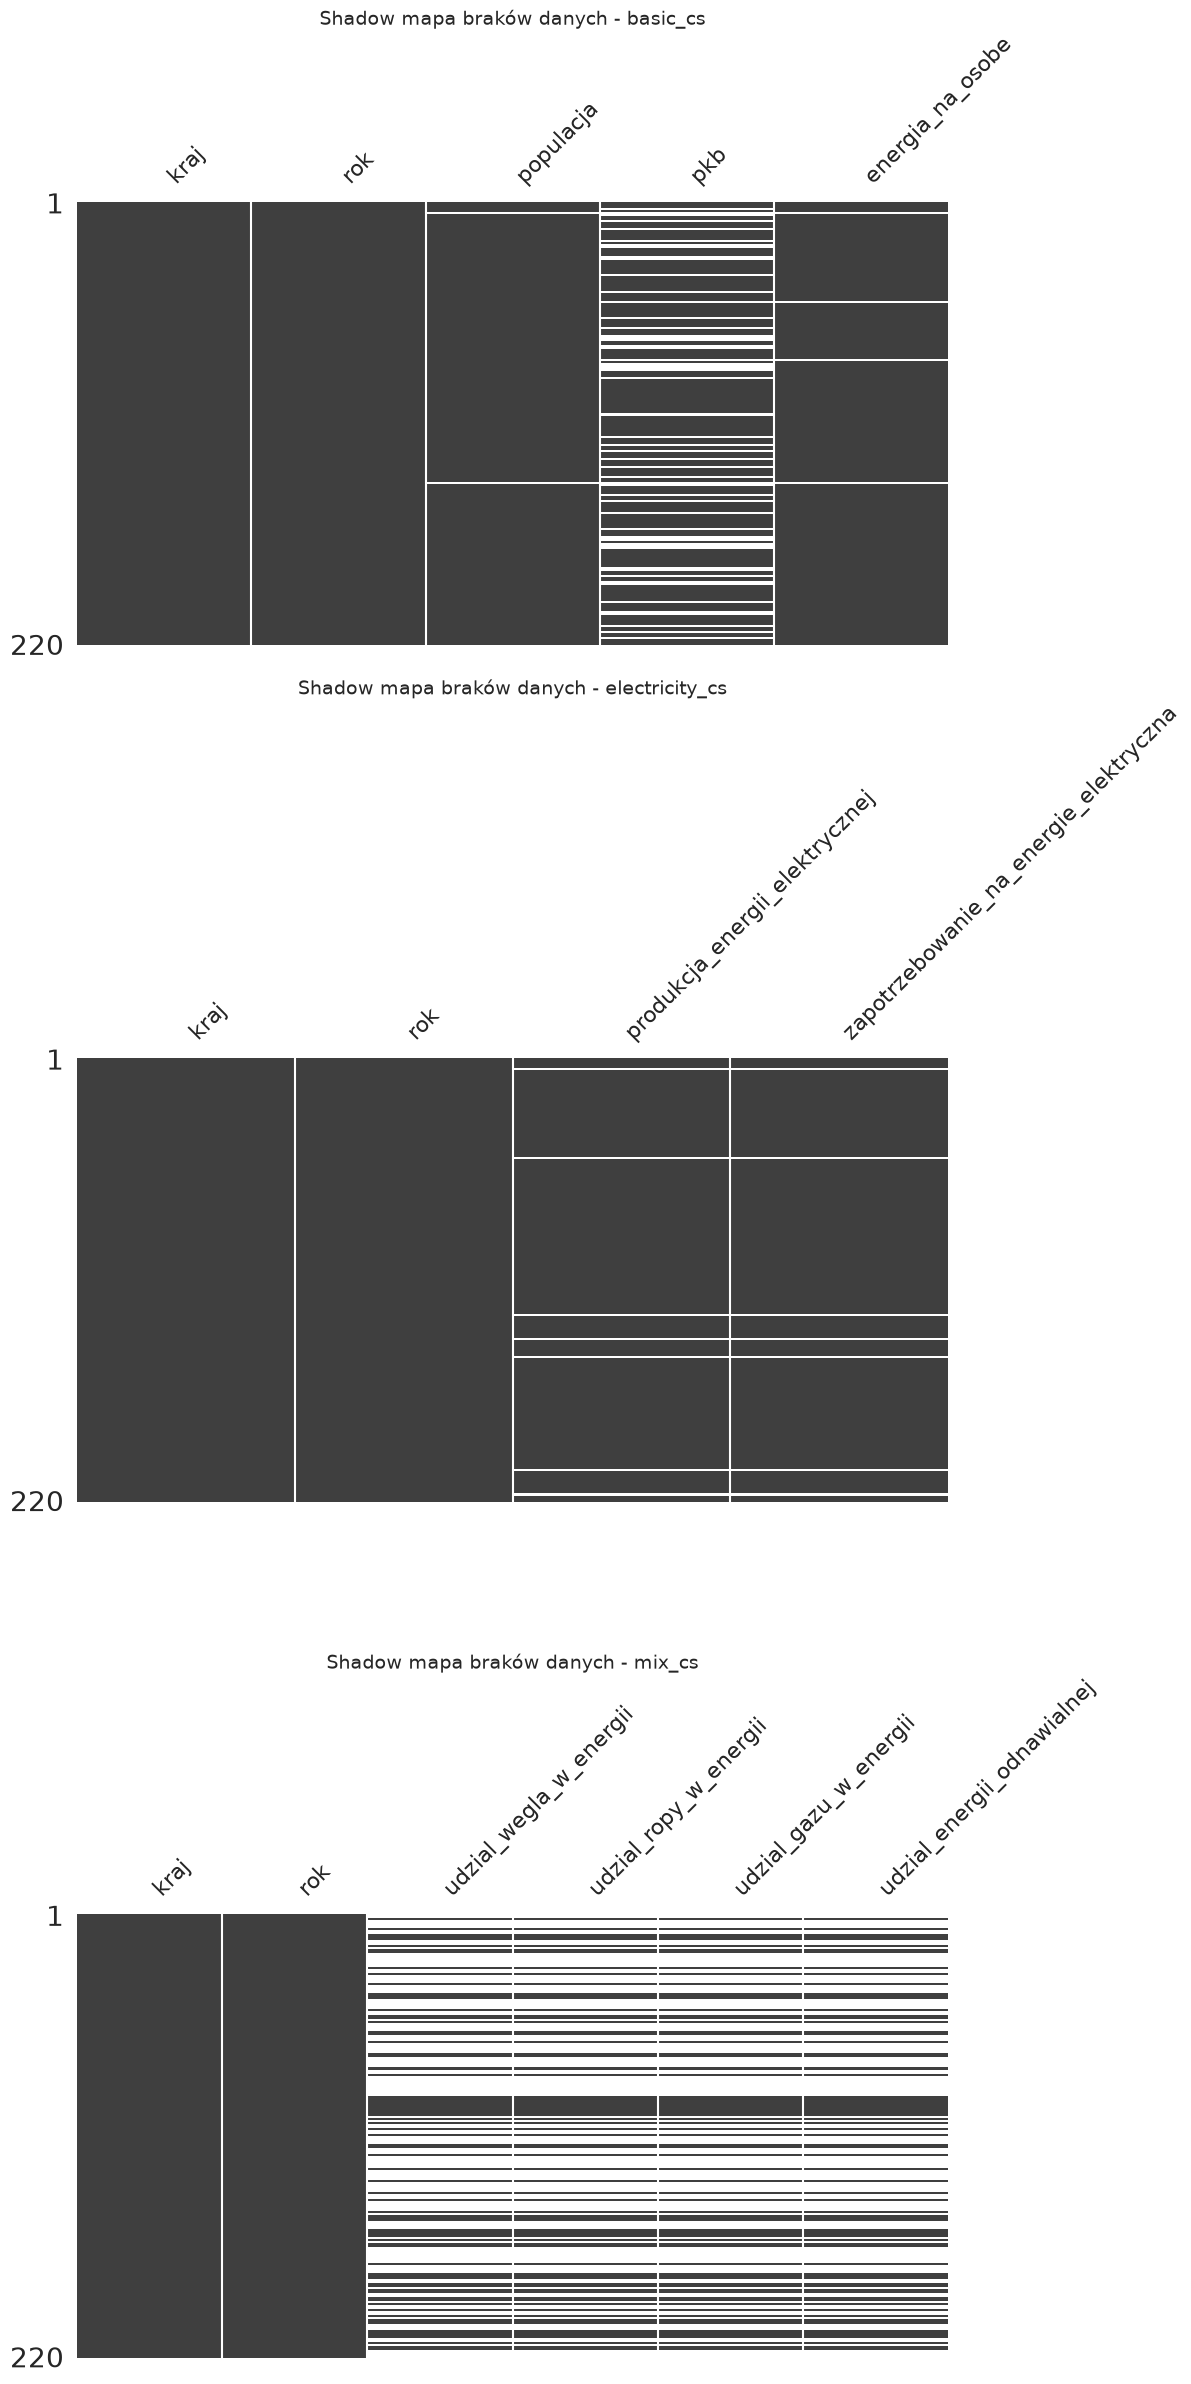

In [185]:
fig, axes = plt.subplots(3, 1, figsize=(12, 24))

msno.matrix(basic_cs, ax=axes[0], sparkline=False)
axes[0].set_title("Shadow mapa braków danych - basic_cs")

msno.matrix(electricity_cs, ax=axes[1], sparkline=False)
axes[1].set_title("Shadow mapa braków danych - electricity_cs")

msno.matrix(mix_cs, ax=axes[2], sparkline=False)
axes[2].set_title("Shadow mapa braków danych - mix_cs")

plt.tight_layout()
plt.show()

Shadow mapy przedstawiają rozmieszczenie brakujących wartości w analizowanych zbiorach danych. We wszystkich trzech zbiorach kolumny `kraj` oraz `rok` są kompletne i nie zawierają brakujących obserwacji.

W zbiorze `basic_cs` największa liczba braków występuje w kolumnach `pkb` oraz `energia_na_osobe`. Braki te są rozproszone i nie tworzą prostego, pojedynczego wzorca.

W zbiorze `electricity_cs` zmienne `produkcja_energii_elektrycznej` i `zapotrzebowanie_na_energie_elektryczna` mają bardzo podobne rozmieszczenie braków, co sugeruje wspólne źródło raportowania.

W zbiorze `mix_cs` braki w udziałach źródeł energii pojawiają się najczęściej równocześnie, co oznacza, że dla części krajów brakuje całego pakietu informacji o miksie energetycznym.

Podsumowanie

Analiza shadow map wskazuje, że brakujące wartości nie są rozmieszczone losowo. Zmienne należące do tej samej grupy tematycznej wykazują bardzo podobny wzorzec braków, co sugeruje ich wspólne źródło. Najiększa liczba braków dotyczy szczegółowych danych mixu energetycznego.

Strategia postępowania z brakującymi danymi

Ponieważ większość braków wynika z ograniczonej dostępności danych historycznych, zrezygnowano z imputacji brakujących wartości. Uzupełnianie ich mogłoby prowadzić do zniekształcenia wyników analizy i błędnej interpretacji trendów. W dalszej części projektu wykorzystano wyłącznie obserwacje zawierające wartości dla zmiennych niezbędnych do realizacji postawionych pytań badawczych.

In [186]:
cross_all = (
    basic_cs
    .merge(electricity_cs, on=["kraj", "rok"], how="inner")
    .merge(mix_cs, on=["kraj", "rok"], how="inner")
)

print("Wymiary cross_all:", cross_all.shape)
cross_all.head()

Wymiary cross_all: (220, 11)


,kraj,rok,populacja,pkb,energia_na_osobe,produkcja_energii_elektrycznej,zapotrzebowanie_na_energie_elektryczna,udzial_wegla_w_energii,udzial_ropy_w_energii,udzial_gazu_w_energii,udzial_energii_odnawialnej
0,Afghanistan,2020,39068933.0,7.141771e+10,1200.743,1.18,6.33,NaN,NaN,NaN,NaN
1,Albania,2020,2871900.0,3.213073e+10,7352.949,5.31,7.59,NaN,NaN,NaN,NaN
2,Algeria,2020,44042041.0,5.598199e+11,14733.622,79.37,79.31,0.235,32.665,66.818,0.283
3,American Samoa,2020,49732.0,NaN,27671.668,0.17,0.17,NaN,NaN,NaN,NaN
4,Angola,2020,33451100.0,1.523087e+11,2281.594,16.81,16.81,NaN,NaN,NaN,NaN


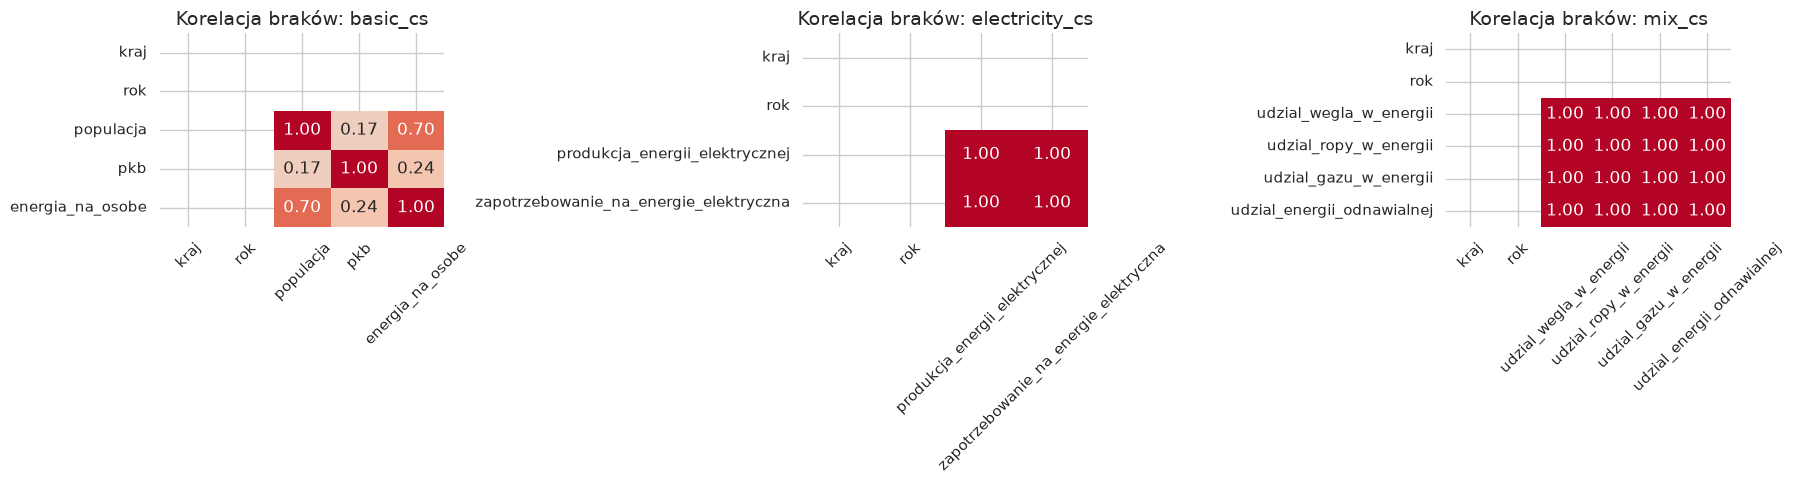

In [187]:
# Heatmapy korelacji braków danych dla zbiorów przekrojowych
datasets = {
    "basic_cs": basic_cs,
    "electricity_cs": electricity_cs,
    "mix_cs": mix_cs,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, df_tmp) in zip(axes, datasets.items()):
    miss_corr = df_tmp.isna().corr()
    sns.heatmap(
        miss_corr,
        ax=ax,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        annot=True,
        fmt=".2f",
        cbar=False
    )
    ax.set_title(f"Korelacja braków: {name}")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Heatmapy przedstawiają stopień współwystępowania brakujących wartości pomiędzy analizowanymi zmiennymi. Wartości na mapach odpowiadają korelacji braków danych – im bliższa wartość 1, tym częściej braki występują jednocześnie w porównywanych zmiennych.

Heatmapa Basic obejmuje zmienne: population, gdp oraz energy_per_capita. Analiza wskazuje na stosunkowo słabą zależność pomiędzy brakami danych w tych zmiennych. Oznacza to, że brak wartości w jednej kolumnie nie musi oznaczać jednoczesnego braku danych w pozostałych zmiennych. Braki mają charakter bardziej niezależny i nie tworzą wyraźnego wspólnego wzorca.

Heatmapa Electricity przedstawia zależność pomiędzy zmiennymi electricity_generation oraz electricity_demand. Uzyskana wartość korelacji braków wynosząca około 1 wskazuje na bardzo silną zgodność ich występowania. Oznacza to, że brak danych dotyczących produkcji energii elektrycznej wiąże się również z brakiem informacji o zapotrzebowaniu na energię elektryczną. Sugeruje to, że obie zmienne pochodzą z tego samego źródła danych i były raportowane równocześnie.

Heatmapa Mix obejmuje zmienne opisujące udział poszczególnych źródeł energii w miksie energetycznym (coal_share_energy, oil_share_energy, gas_share_energy oraz renewables_share_energy). Wszystkie pary zmiennych osiągają współczynnik korelacji braków równy 1,0, co oznacza pełną zgodność wzorca brakujących danych. W praktyce oznacza to, że jeżeli dla danej obserwacji brakuje informacji o udziale jednego źródła energii, to jednocześnie brakuje danych dla wszystkich pozostałych zmiennych opisujących miks energetyczny. Świadczy to o tym, że dane dotyczące struktury miksu energetycznego były udostępniane jako kompletny zestaw informacji.

Podsumowanie

Analiza heatmap potwierdza, że brakujące wartości nie występują losowo. Zmienne należące do tej samej grupy tematycznej charakteryzują się wysoką korelacją braków danych, co wskazuje na ich wspólne źródło oraz sposób raportowania. Najsilniejszą zależność zaobserwowano dla zmiennych opisujących strukturę miksu energetycznego oraz produkcji i zapotrzebowania na energię elektryczną, gdzie współczynnik korelacji braków osiąga wartość 1,0. Wyniki te są zgodne z obserwacjami uzyskanymi na podstawie shadow map i potwierdzają, że brak danych wynika przede wszystkim z niedostępności całych zestawów informacji dla określonych krajów lub lat, a nie z przypadkowych braków pojedynczych wartości.

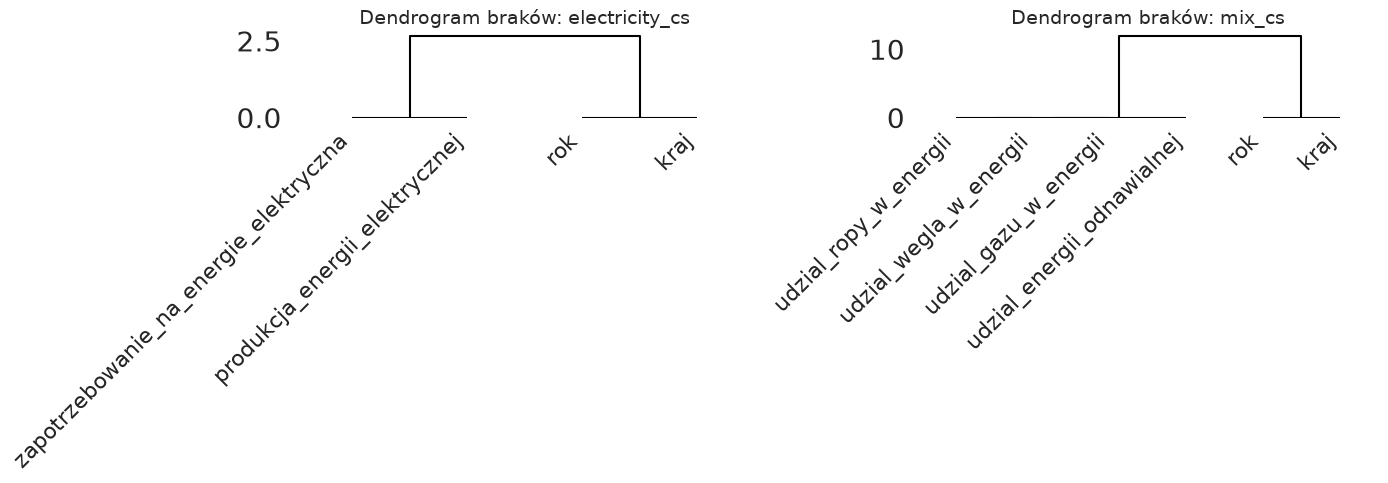

In [188]:
# Dendrogram braków danych
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

msno.dendrogram(electricity_cs, ax=axes[0], orientation="top")
axes[0].set_title("Dendrogram braków: electricity_cs")

msno.dendrogram(mix_cs, ax=axes[1], orientation="top")
axes[1].set_title("Dendrogram braków: mix_cs")

plt.tight_layout()
plt.show()

Dendrogram brakujących danych przedstawia podobieństwo wzorców występowania braków pomiędzy analizowanymi zmiennymi. Zmienne połączone na niższych poziomach drzewa charakteryzują się bardziej zbliżonym rozmieszczeniem brakujących wartości, natomiast połączenia na wyższych poziomach wskazują na mniejsze podobieństwo. Analiza dendrogramów potwierdziła wyniki uzyskane na podstawie shadow map oraz heatmap. Zmienne dotyczące produkcji i zapotrzebowania na energię elektryczną tworzą wspólną grupę, co świadczy o bardzo podobnym wzorcu braków. Jeszcze silniejszą zależność zaobserwowano dla zmiennych opisujących strukturę miksu energetycznego, które zostały połączone w jedną zwartą gałąź, wskazując na niemal identyczne występowanie braków danych. Wyniki sugerują, że braki wynikają z jednoczesnej niedostępności całych zestawów informacji dla wybranych krajów lub lat, a nie z losowego braku pojedynczych obserwacji.

In [189]:
corr_cols = [
    "populacja",
    "pkb",
    "energia_na_osobe",
    "produkcja_energii_elektrycznej",
    "zapotrzebowanie_na_energie_elektryczna",
    "udzial_wegla_w_energii",
    "udzial_ropy_w_energii",
    "udzial_gazu_w_energii",
    "udzial_energii_odnawialnej"
]

cross_all_clean = cross_all.dropna(subset=corr_cols).copy()

print("Wymiary cross_all_clean:", cross_all_clean.shape)
cross_all_clean[corr_cols].head()

Wymiary cross_all_clean: (79, 11)


,populacja,pkb,energia_na_osobe,produkcja_energii_elektrycznej,zapotrzebowanie_na_energie_elektryczna,udzial_wegla_w_energii,udzial_ropy_w_energii,udzial_gazu_w_energii,udzial_energii_odnawialnej
2,44042041.0,5.598199e+11,14733.622,79.37,79.31,0.235,32.665,66.818,0.283
7,45191917.0,7.358142e+11,19117.844,144.64,149.35,1.167,32.910,51.208,11.833
10,25743732.0,1.232260e+12,61584.387,265.15,265.15,29.709,33.141,26.858,10.292
11,8921362.0,3.632811e+11,44852.355,69.04,71.24,7.409,33.949,21.762,36.880
12,10181688.0,1.586975e+11,18162.854,25.75,24.74,0.002,31.262,66.945,1.790


# 3. Wizualizacje (analiza przekrojowa)

W tej sekcji każda obserwacja odpowiada pojedynczemu krajowi w wybranym roku (`rok_przekrojowy`).

In [190]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Pracujemy przekrojowo: jedna obserwacja = kraj w wybranym roku
df_cs = cross_all.copy()
required_cols = [
    "kraj", "rok", "populacja", "pkb", "energia_na_osobe",
    "produkcja_energii_elektrycznej", "zapotrzebowanie_na_energie_elektryczna",
    "udzial_wegla_w_energii", "udzial_ropy_w_energii", "udzial_gazu_w_energii",
    "udzial_energii_odnawialnej"
]
df_cs = df_cs.dropna(subset=required_cols).copy()

# Zmienne pomocnicze do przekrojów
df_cs["udzial_kopalny_w_energii"] = (
    df_cs["udzial_wegla_w_energii"]
    + df_cs["udzial_ropy_w_energii"]
    + df_cs["udzial_gazu_w_energii"]
)
df_cs["gdp_per_capita"] = df_cs["pkb"] / df_cs["populacja"]

pkb_rank = df_cs["pkb"].rank(method="first")
df_cs["grupa_pkb"] = pd.qcut(
    pkb_rank,
    q=3,
    labels=["niski PKB", "średni PKB", "wysoki PKB"]
)

df_cs["standard_miksu"] = pd.cut(
    df_cs["udzial_energii_odnawialnej"],
    bins=[-0.1, 25, 50, 100],
    labels=["niski udział OZE", "średni udział OZE", "wysoki udział OZE"]
)

print(f"Rok analizy przekrojowej: {rok_przekrojowy}")
print(f"Liczba obserwacji po czyszczeniu: {len(df_cs)}")
df_cs[["kraj", "rok", "energia_na_osobe", "grupa_pkb", "standard_miksu"]].head()

Rok analizy przekrojowej: 2020
Liczba obserwacji po czyszczeniu: 79


,kraj,rok,energia_na_osobe,grupa_pkb,standard_miksu
2,Algeria,2020,14733.622,średni PKB,niski udział OZE
7,Argentina,2020,19117.844,średni PKB,niski udział OZE
10,Australia,2020,61584.387,wysoki PKB,niski udział OZE
11,Austria,2020,44852.355,średni PKB,średni udział OZE
12,Azerbaijan,2020,18162.854,niski PKB,niski udział OZE


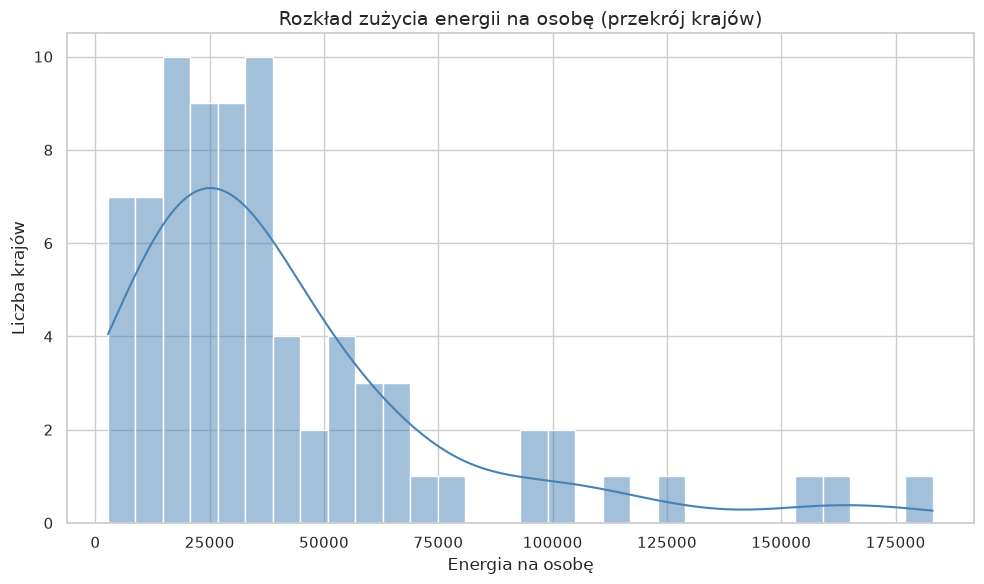

In [191]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_cs, x="energia_na_osobe", bins=30, kde=True, color="steelblue")
plt.title("Rozkład zużycia energii na osobę (przekrój krajów)")
plt.xlabel("Energia na osobę")
plt.ylabel("Liczba krajów")
plt.tight_layout()
plt.show()

Histogram pokazuje, że rozkład zużycia energii na osobę jest asymetryczny: większość krajów skupia się przy niższych wartościach, a niewielka grupa ma bardzo wysokie poziomy.
Sugeruje to silne zróżnicowanie energetyczne pomiędzy krajami.

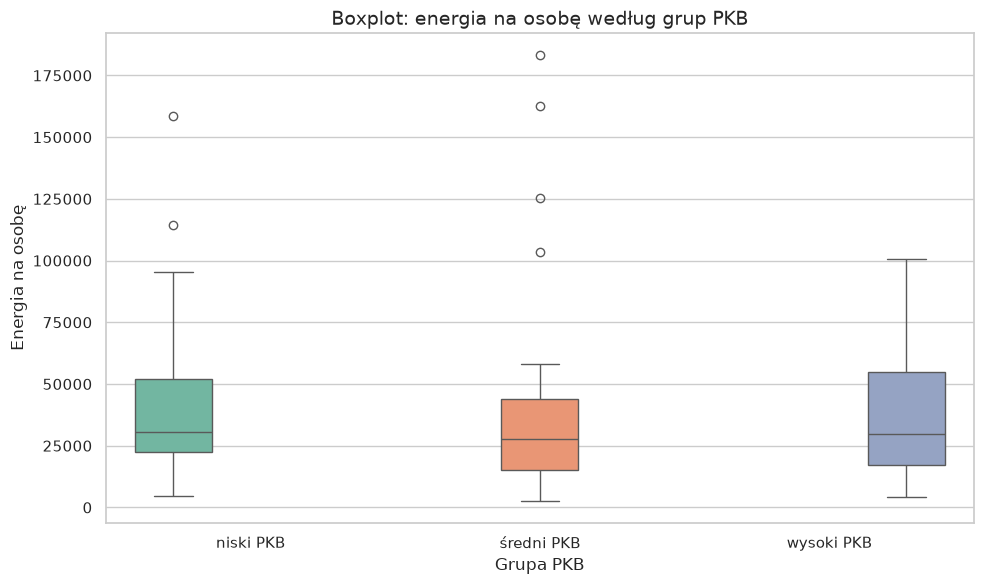

In [192]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_cs,
    x="grupa_pkb",
    y="energia_na_osobe",
    hue="grupa_pkb",
    palette="Set2",
    legend=False
)
plt.title("Boxplot: energia na osobę według grup PKB")
plt.xlabel("Grupa PKB")
plt.ylabel("Energia na osobę")
plt.tight_layout()
plt.show()

Boxplot wskazuje, że kraje o wyższym PKB mają zwykle wyższe zużycie energii na osobę.
Jednocześnie duża rozpiętość pudełek i obecność obserwacji odstających pokazują, że zależność nie jest idealnie jednorodna.

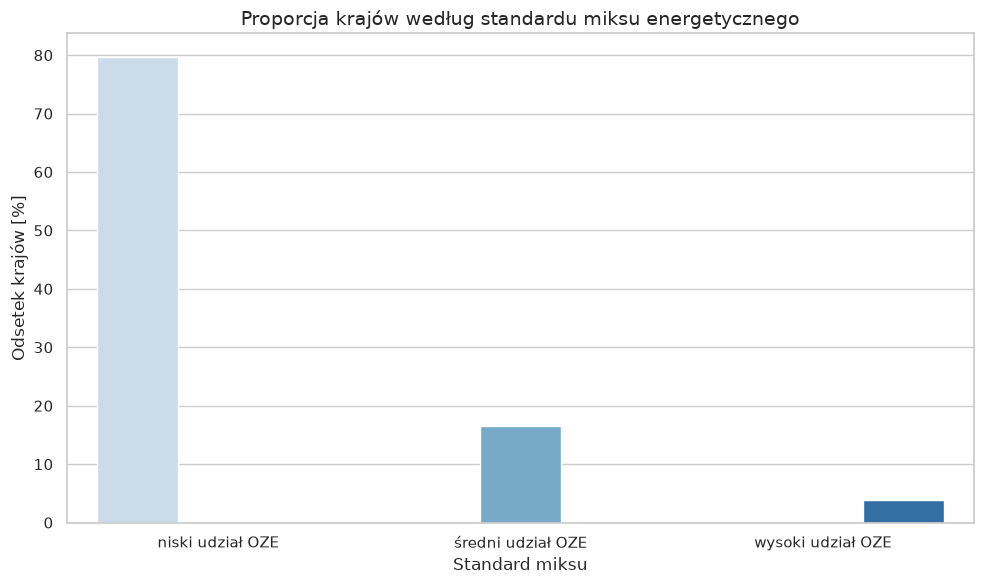

In [193]:
standard_share = (
    df_cs["standard_miksu"]
    .value_counts(normalize=True)
    .mul(100)
    .rename_axis("standard_miksu")
    .reset_index(name="procent_krajow")
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=standard_share,
    x="standard_miksu",
    y="procent_krajow",
    hue="standard_miksu",
    palette="Blues",
    legend=False
)
plt.title("Proporcja krajów według standardu miksu energetycznego")
plt.xlabel("Standard miksu")
plt.ylabel("Odsetek krajów [%]")
plt.tight_layout()
plt.show()

Wykres słupkowy przedstawia proporcję krajów według standardu miksu energetycznego (niski, średni i wysoki udział OZE).
Dzięki temu łatwo ocenić, jaka część krajów znajduje się już w bardziej „zielonym” modelu energetycznym.

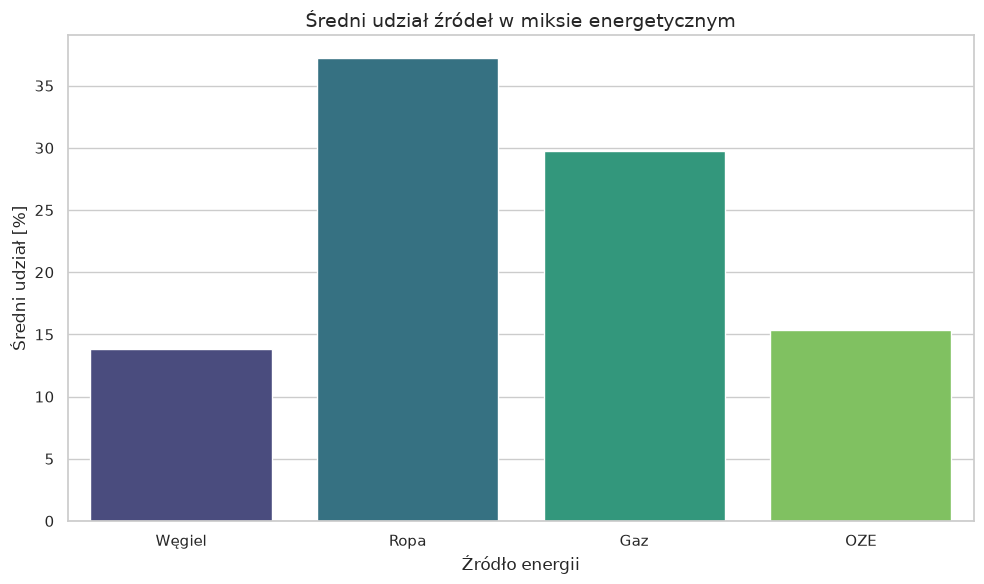

In [194]:
mix_mean = (
    df_cs[[
        "udzial_wegla_w_energii",
        "udzial_ropy_w_energii",
        "udzial_gazu_w_energii",
        "udzial_energii_odnawialnej"
    ]]
    .mean()
    .reset_index()
    .rename(columns={"index": "zrodlo", 0: "sredni_udzial"})
)

etykiety = {
    "udzial_wegla_w_energii": "Węgiel",
    "udzial_ropy_w_energii": "Ropa",
    "udzial_gazu_w_energii": "Gaz",
    "udzial_energii_odnawialnej": "OZE"
}
mix_mean["zrodlo"] = mix_mean["zrodlo"].map(etykiety)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=mix_mean,
    x="zrodlo",
    y="sredni_udzial",
    hue="zrodlo",
    palette="viridis",
    legend=False
)
plt.title("Średni udział źródeł w miksie energetycznym")
plt.xlabel("Źródło energii")
plt.ylabel("Średni udział [%]")
plt.tight_layout()
plt.show()

Średnie udziały źródeł energii pokazują dominujące elementy miksu w analizowanym przekroju krajów.
Porównanie słupków pozwala szybko ocenić relatywną rolę paliw kopalnych i OZE.

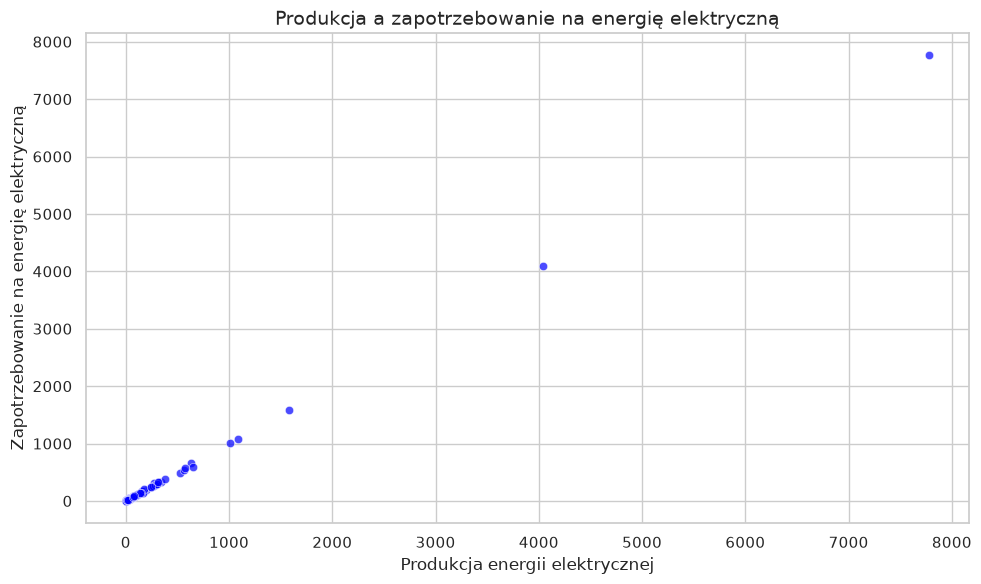

In [195]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cs,
    x="produkcja_energii_elektrycznej",
    y="zapotrzebowanie_na_energie_elektryczna",
    alpha=0.7,
    color="blue"
    )
plt.title("Produkcja a zapotrzebowanie na energię elektryczną")
plt.xlabel("Produkcja energii elektrycznej")
plt.ylabel("Zapotrzebowanie na energię elektryczną")
plt.tight_layout()
plt.show()

Wykres punktowy sugeruje dodatnią zależność między produkcją i zapotrzebowaniem na energię elektryczną.
Kraje o większej produkcji mają zwykle wyższy popyt, choć widoczna jest także grupa odstających obserwacji.

# 4. Analiza opisowa

In [196]:
# Analiza 1: statystyki opisowe energii na osobę ogółem i wg grup PKB
desc_global = df_cs[["energia_na_osobe", "gdp_per_capita", "udzial_energii_odnawialnej"]].describe().T

desc_group = (
    df_cs.groupby("grupa_pkb", observed=False)["energia_na_osobe"]
    .describe()
    .round(2)
)

print("--- Statystyki opisowe (ogółem) ---")
print(tabulate(desc_global.round(2), headers="keys", tablefmt="github"))

print("\n--- Energia na osobę wg grup PKB ---")
print(tabulate(desc_group, headers="keys", tablefmt="github"))

--- Statystyki opisowe (ogółem) ---
|                            |   count |     mean |      std |     min |      25% |      50% |      75% |       max |
|----------------------------|---------|----------|----------|---------|----------|----------|----------|-----------|
| energia_na_osobe           |      79 | 41367    | 36749.4  | 2750.77 | 18805.5  | 29845.6  | 54826.1  | 183126    |
| gdp_per_capita             |      79 | 29597.2  | 20621    | 4536.18 | 14308.2  | 25333.9  | 39115    | 128603    |
| udzial_energii_odnawialnej |      79 |    15.34 |    15.88 |    0.01 |     4.02 |    10.64 |    20.42 |     86.13 |

--- Energia na osobę wg grup PKB ---
| grupa_pkb   |   count |    mean |     std |     min |     25% |     50% |     75% |    max |
|-------------|---------|---------|---------|---------|---------|---------|---------|--------|
| niski PKB   |      27 | 42930.1 | 34687.9 | 4653.04 | 22414.5 | 30643.5 | 51988.9 | 158445 |
| średni PKB  |      26 | 43962.3 | 47337.1 | 2750.

Statystyki opisowe potwierdzają duże zróżnicowanie zużycia energii na osobę między krajami (szeroki zakres i duże odchylenie standardowe).
W przekroju według grup PKB widoczne są różnice poziomów, ale zależność nie jest idealnie monotoniczna, co sugeruje wpływ dodatkowych czynników (np. struktury przemysłu lub miksu energetycznego).

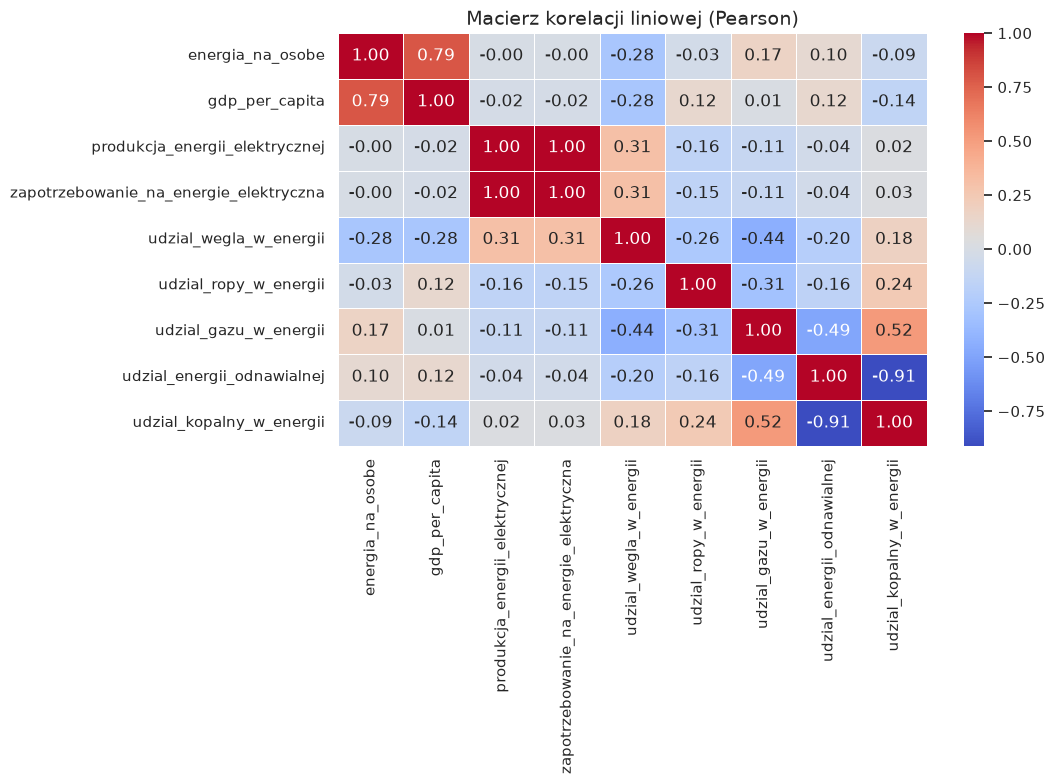

In [197]:
# Analiza 2: korelacja liniowa (Pearson)
corr_cols = [
    "energia_na_osobe",
    "gdp_per_capita",
    "produkcja_energii_elektrycznej",
    "zapotrzebowanie_na_energie_elektryczna",
    "udzial_wegla_w_energii",
    "udzial_ropy_w_energii",
    "udzial_gazu_w_energii",
    "udzial_energii_odnawialnej",
    "udzial_kopalny_w_energii"
]

corr_pearson = df_cs[corr_cols].corr(method="pearson")

plt.figure(figsize=(11, 8))
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Macierz korelacji liniowej (Pearson)")
plt.tight_layout()
plt.show()

Macierz Pearsona pokazuje, że najsilniejsze zależności liniowe dotyczą par zmiennych technicznie powiązanych (np. produkcja i zapotrzebowanie energii elektrycznej).
W przypadku relacji między energią na osobę, poziomem PKB i udziałami źródeł energii zależności są zróżnicowane... 

# 5. Wnioski końcowe

1. Po dostosowaniu danych do analizy przekrojowej możliwe było porównanie krajów w jednym roku i wskazanie dużego zróżnicowania poziomu konsumpcji energii oraz struktury miksu energetycznego.
2. Energia na osobę różni się między grupami PKB, ale obserwowany układ nie jest idealnie liniowy ani monotoniczny, co wskazuje na znaczenie dodatkowych uwarunkowań.
3. Udział OZE istotnie różnicuje kraje w przekroju, jednak w wielu obserwacjach paliwa kopalne nadal stanowią dominującą część miksu energetycznego.
4. Wnioski do analizy opisowej ... 
5. Ograniczenia: analiza dotyczy jednego roku i korzysta z podejścia complete-case; dalszym krokiem może być porównanie przekrojów dla kilku wybranych lat oraz analiza regionalna.